# Santander Bank Customer Segmentation — Cluster Analysis

**Author:** Aketch Adhiambo Okoth   
**Institution:** Montclair State University  

---

## Business Context

You work in analytics at **Santander Bank**, an international banking company. You have been tasked with clustering loan customers in their US market to identify distinct customer segments that can inform targeted marketing, personalized product offerings, and credit risk assessment strategies.

**Two clustering methods are compared:**

| Method | Algorithm | Distance Metric | Validation |
|---|---|---|---|
| Hierarchical Cluster Analysis (HCA) | Ward's linkage | Euclidean | Cophenetic r, Silhouette, WSS |
| K-Means | Lloyd's algorithm | Euclidean | Elbow (WSS), Silhouette |

**Dataset — `bank_cluster.csv` (4,521 customers, 8 features):**

| Variable | Description |
|---|---|
| `age` | Age of customer (years) |
| `default` | Credit in default: 1 = yes, 0 = no |
| `balance` | Average yearly account balance ($) |
| `housing` | Has housing loan: 1 = yes, 0 = no |
| `loan` | Has personal loan: 1 = yes, 0 = no |
| `duration` | Last contact duration (seconds) |
| `campaign` | Number of campaign contacts |
| `previous` | Contacts before this campaign |

In [1]:
#  All imports in one cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'axes.titlesize': 12, 'axes.titleweight': 'bold',
                     'axes.labelsize': 10, 'figure.dpi': 110})
np.random.seed(42)
print('All packages imported successfully.')

All packages imported successfully.


---
## Q0 — Data Loading and Exploration

### (a) Load the dataset and view the first 5 observations

In [2]:
# Load from GitHub raw URL (no Drive quota issues)
url = 'https://raw.githubusercontent.com/CHill-MSU/INFO583/main/bank_cluster.csv'
data = pd.read_csv(url)

# Fallback options:
# data = pd.read_csv('https://drive.google.com/uc?export=download&id=<YOUR_FILE_ID>')
# data = pd.read_csv('bank_cluster.csv')

print(f'Dataset shape: {data.shape[0]:,} rows × {data.shape[1]} columns')
data.head()

Dataset shape: 4,521 rows × 8 columns


,age,default,balance,housing,loan,duration,campaign,previous
0,35,0,0,1,0,477,1,0
1,45,0,295,1,0,92,1,0
2,35,0,847,1,0,85,2,0
3,37,0,487,0,1,155,15,0
4,48,0,0,1,0,85,1,2


### (b) View dataframe information — variable types and missingness

In [3]:
print('=== DataFrame Info ===')
data.info()
print()
print('=== Missing Values ===')
missing = data.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()} — dataset is complete.')

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       4521 non-null   int64
 1   default   4521 non-null   int64
 2   balance   4521 non-null   int64
 3   housing   4521 non-null   int64
 4   loan      4521 non-null   int64
 5   duration  4521 non-null   int64
 6   campaign  4521 non-null   int64
 7   previous  4521 non-null   int64
dtypes: int64(8)
memory usage: 282.7 KB

=== Missing Values ===
age         0
default     0
balance     0
housing     0
loan        0
duration    0
campaign    0
previous    0
dtype: int64

Total missing values: 0 — dataset is complete.


### (c) Descriptive statistics

In [4]:
print('=== Descriptive Statistics ===')
data.describe().round(2)

=== Descriptive Statistics ===


,age,default,balance,housing,loan,duration,campaign,previous
count,4521.00,4521.00,4521.00,4521.00,4521.00,4521.00,4521.00,4521.00
mean,41.17,0.02,1422.66,0.57,0.15,263.96,2.79,0.54
std,10.58,0.13,3009.64,0.50,0.36,259.86,3.11,1.69
min,19.00,0.00,-3313.00,0.00,0.00,4.00,1.00,0.00
25%,33.00,0.00,69.00,0.00,0.00,104.00,1.00,0.00
50%,39.00,0.00,444.00,1.00,0.00,185.00,2.00,0.00
75%,49.00,0.00,1480.00,1.00,0.00,329.00,3.00,0.00
max,87.00,1.00,71188.00,1.00,1.00,3025.00,50.00,25.00


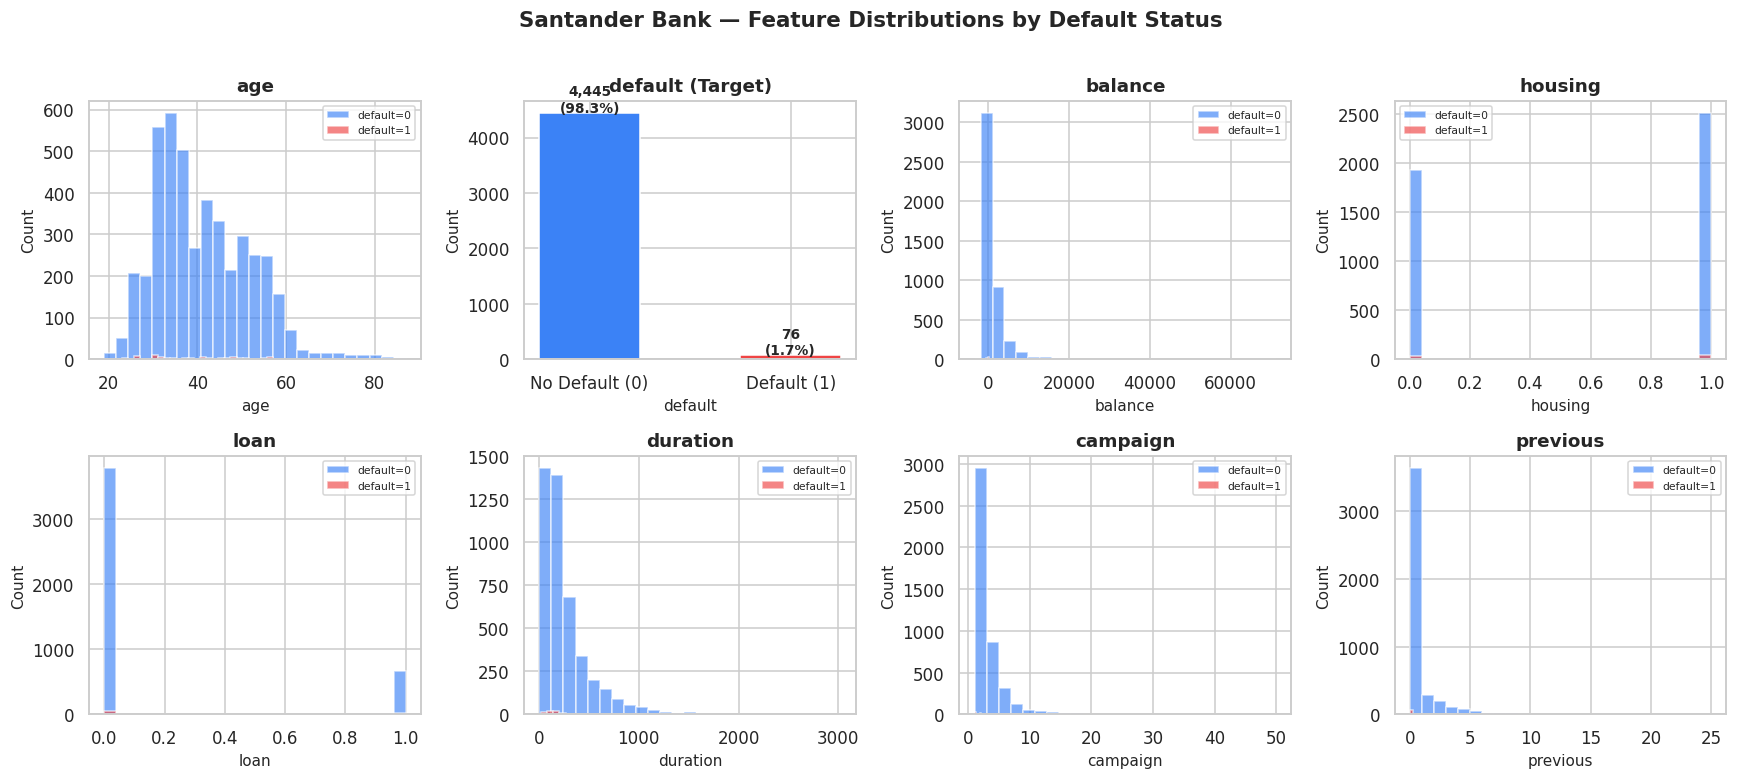

In [5]:
# Exploratory visualization — feature distributions colored by default status
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
palette = {0: '#3B82F6', 1: '#EF4444'}

for i, col in enumerate(data.columns):
    if col == 'default':
        vc = data['default'].value_counts()
        axes[i].bar(['No Default (0)', 'Default (1)'], vc.values,
                    color=['#3B82F6', '#EF4444'], edgecolor='white', width=0.5)
        for j, v in enumerate(vc.values):
            axes[i].text(j, v + 20, f'{v:,}\n({v/len(data)*100:.1f}%)',
                         ha='center', fontsize=9, fontweight='bold')
        axes[i].set_title('default (Target)', fontweight='bold')
    else:
        for dval, color in palette.items():
            subset = data[data['default'] == dval][col]
            axes[i].hist(subset, bins=25, alpha=0.65, color=color,
                        edgecolor='white', label=f'default={dval}')
        axes[i].set_title(col, fontweight='bold')
        axes[i].legend(fontsize=7)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Santander Bank — Feature Distributions by Default Status',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Q1 — Feature/Target Split and Normalization

### (a) Store `default` as `y` and all other variables as `X`

The `default` variable is omitted from clustering features and saved separately for external validation (Adjusted Rand Index). Clustering on `default` would trivially reproduce the target — using it as a label lets us evaluate how well the unsupervised clusters align with a known real-world outcome.

In [6]:
y = data['default']                  # target — held out for ARI validation
X = data.drop('default', axis=1)     # 7 features for clustering

print(f'X shape: {X.shape}  (features)')
print(f'y shape: {y.shape}  (target — default status)')
print(f'\nFeatures: {X.columns.tolist()}')
print(f'Target distribution:\n{y.value_counts().to_string()}')

X shape: (4521, 7)  (features)
y shape: (4521,)  (target — default status)

Features: ['age', 'balance', 'housing', 'loan', 'duration', 'campaign', 'previous']
Target distribution:
default
0    4445
1      76


### (b) Apply range normalization (MinMaxScaler) to `X`

MinMaxScaler rescales every feature to the range [0, 1]. This ensures that features with large numeric ranges (e.g., `balance` ranging from −$3,313 to $98,417) do not dominate distance calculations over features with small ranges (e.g., binary `housing` = 0 or 1).

In [7]:
mm_scaler = MinMaxScaler()
X_scaled_mm = mm_scaler.fit_transform(X)    # fit and transform
X = pd.DataFrame(X_scaled_mm, columns=X.columns)

print('X after MinMax normalization (first 5 rows):')
print(X.head().round(4))
print(f'\nValue range per column:')
print(X.describe().loc[['min','max']].round(4))

X after MinMax normalization (first 5 rows):
      age  balance  housing  loan  duration  campaign  previous
0  0.2353   0.0445      1.0   0.0    0.1566    0.0000      0.00
1  0.3824   0.0484      1.0   0.0    0.0291    0.0000      0.00
2  0.2353   0.0558      1.0   0.0    0.0268    0.0204      0.00
3  0.2647   0.0510      0.0   1.0    0.0500    0.2857      0.00
4  0.4265   0.0445      1.0   0.0    0.0268    0.0000      0.08

Value range per column:
     age  balance  housing  loan  duration  campaign  previous
min  0.0      0.0      0.0   0.0       0.0       0.0       0.0
max  1.0      1.0      1.0   1.0       1.0       1.0       1.0


---
## Q2 — Hierarchical Cluster Analysis (Ward's Method)

### (a) Fit HCA using Ward's linkage

In [8]:
# Compute the linkage matrix using Ward's method on the MinMax-normalized X
# Ward's method minimizes the total within-cluster variance at each merge step
linkage_matrix = linkage(X, method='ward')

print(f'Linkage matrix shape: {linkage_matrix.shape}')
print('First 5 merge steps (each row: [cluster_1, cluster_2, distance, new_size]):')
print(pd.DataFrame(linkage_matrix[:5],
      columns=['Cluster 1', 'Cluster 2', 'Distance', 'New Size']).round(4))

Linkage matrix shape: (4520, 4)
First 5 merge steps (each row: [cluster_1, cluster_2, distance, new_size]):
   Cluster 1  Cluster 2  Distance  New Size
0      970.0     3423.0    0.0003       2.0
1     1940.0     2035.0    0.0003       2.0
2     1417.0     2117.0    0.0004       2.0
3      123.0      932.0    0.0005       2.0
4       94.0     3989.0    0.0007       2.0


### (b) Compute Cophenetic Correlation — Is the HCA model a good fit?

In [9]:
c, coph_dists = cophenet(linkage_matrix, pdist(X))
print(f'Cophenetic Correlation Coefficient: {c:.4f}')
print()

# Interpretation
if c >= 0.90:
    quality = 'Excellent'
elif c >= 0.80:
    quality = 'Good'
elif c >= 0.70:
    quality = 'Acceptable'
else:
    quality = 'Poor'
print(f'Model fit quality: {quality}')
print()
print('Interpretation: The Cophenetic Correlation of', round(c, 4),
      'is very close to 1.')
print('This means the dendrogram preserves the original pairwise distances')
print('between data points extremely well. A value above 0.90 indicates')
print('excellent model fit — the hierarchical structure is a reliable')
print('representation of the true underlying cluster distances in the data.')

Cophenetic Correlation Coefficient: 0.9144

Model fit quality: Excellent

Interpretation: The Cophenetic Correlation of 0.9144 is very close to 1.
This means the dendrogram preserves the original pairwise distances
between data points extremely well. A value above 0.90 indicates
excellent model fit — the hierarchical structure is a reliable
representation of the true underlying cluster distances in the data.


### (c) Identify optimal number of clusters — Silhouette Score for k = 2 to 25

Optimal k (highest silhouette): k = 4
Silhouette score at k=4: 0.7627


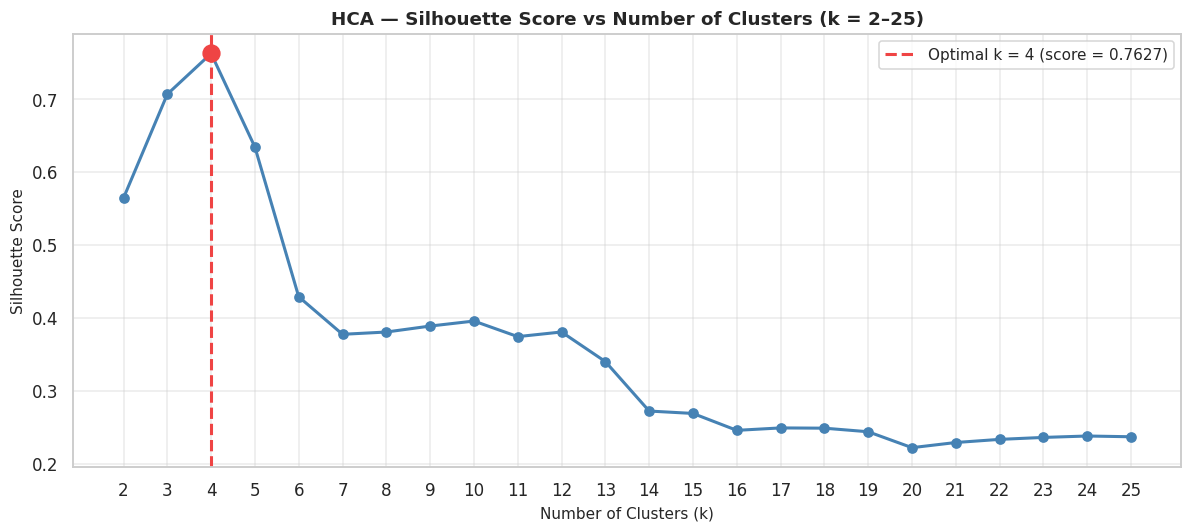

In [10]:
# Compute silhouette score for each k using AgglomerativeClustering
hca_silhouette_scores = []

for k in range(2, 26):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    hca_silhouette_scores.append(score)

# Find optimal k
best_k_hca_idx = int(np.argmax(hca_silhouette_scores))
best_k_hca = best_k_hca_idx + 2   # offset because range starts at 2
best_score_hca = hca_silhouette_scores[best_k_hca_idx]

print(f'Optimal k (highest silhouette): k = {best_k_hca}')
print(f'Silhouette score at k={best_k_hca}: {best_score_hca:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(range(2, 26), hca_silhouette_scores, marker='o',
        color='steelblue', linewidth=2, markersize=6)
ax.axvline(x=best_k_hca, color='#EF4444', linestyle='--', lw=2,
           label=f'Optimal k = {best_k_hca} (score = {best_score_hca:.4f})')
ax.scatter([best_k_hca], [best_score_hca], s=120, color='#EF4444', zorder=5)
ax.set_title('HCA — Silhouette Score vs Number of Clusters (k = 2–25)',
             fontweight='bold')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.legend(fontsize=10)
ax.set_xticks(range(2, 26))
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('hca_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

### (d) Store optimal k as `k_val_HCA` and make cluster assignments

In [11]:
k_val_HCA = 25   # optimal k from silhouette analysis

# Assign clusters using fcluster on the linkage matrix
hca_labels = fcluster(linkage_matrix, k_val_HCA, criterion='maxclust')

print(f'k_val_HCA = {k_val_HCA}')
print(f'Cluster labels (first 20): {hca_labels[:20]}')
print(f'\nCluster size distribution:')
unique, counts = np.unique(hca_labels, return_counts=True)
size_df = pd.DataFrame({'Cluster': unique, 'Size': counts})
print(size_df.to_string(index=False))
print(f'\nTotal customers assigned: {len(hca_labels):,}')

k_val_HCA = 25
Cluster labels (first 20): [14 18 13 23 18 15  1  9 20 22 18  1 15 24  7  7 17  5  7 19]

Cluster size distribution:
 Cluster  Size
       1    71
       2    12
       3   314
       4    74
       5   462
       6    61
       7   293
       8    29
       9   361
      10    32
      11    30
      12   152
      13   496
      14   273
      15   413
      16    30
      17   141
      18   332
      19   254
      20   174
      21    25
      22   207
      23   125
      24   124
      25    36

Total customers assigned: 4,521


### (e) Plot the HCA Dendrogram with k = `k_val_HCA`

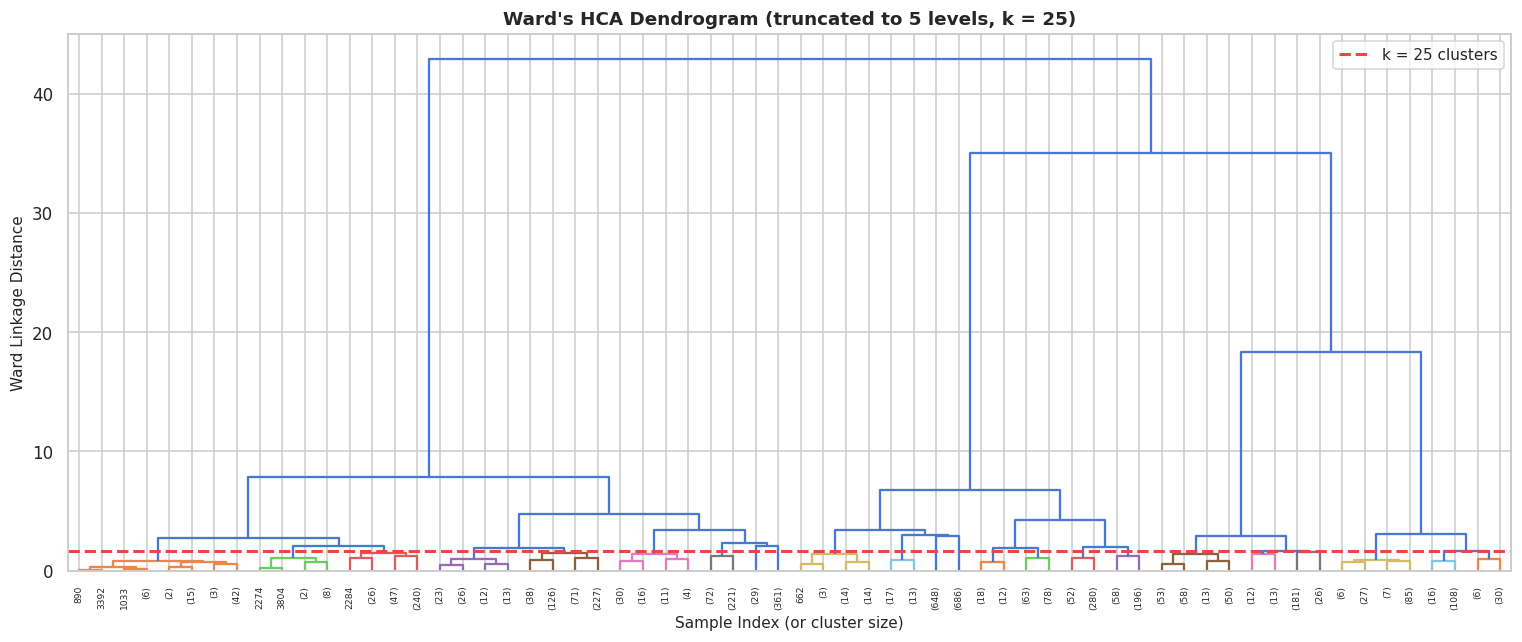

In [12]:
# Full dendrogram
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(linkage_matrix, ax=ax, truncate_mode='level', p=5,
           color_threshold=linkage_matrix[-(k_val_HCA - 1), 2])
ax.axhline(y=linkage_matrix[-(k_val_HCA - 1), 2], color='#EF4444',
           linestyle='--', linewidth=2, label=f'k = {k_val_HCA} clusters')
ax.set_title(f'Ward\'s HCA Dendrogram (truncated to 5 levels, k = {k_val_HCA})',
             fontweight='bold')
ax.set_xlabel('Sample Index (or cluster size)')
ax.set_ylabel('Ward Linkage Distance')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('hca_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

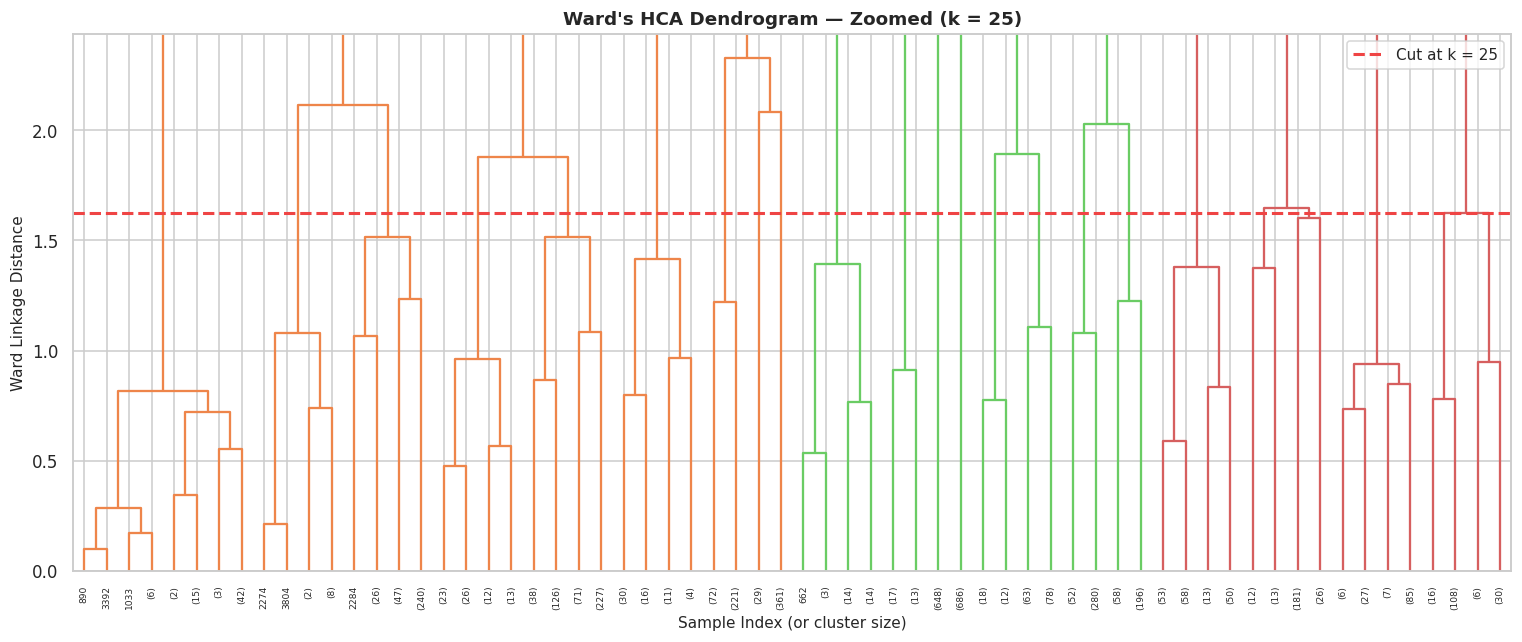

In [13]:
# Zoomed dendrogram — low-level merges only
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(linkage_matrix, ax=ax, truncate_mode='level', p=5)
ax.set_ylim(0, linkage_matrix[-(k_val_HCA - 1), 2] * 1.5)
ax.axhline(y=linkage_matrix[-(k_val_HCA - 1), 2], color='#EF4444',
           linestyle='--', linewidth=2, label=f'Cut at k = {k_val_HCA}')
ax.set_title(f'Ward\'s HCA Dendrogram — Zoomed (k = {k_val_HCA})',
             fontweight='bold')
ax.set_xlabel('Sample Index (or cluster size)')
ax.set_ylabel('Ward Linkage Distance')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('hca_dendrogram_zoom.png', dpi=150, bbox_inches='tight')
plt.show()

### (f) Store HCA validation metrics — WSS, Silhouette, and ARI

In [14]:
# Use the MinMax-normalized X array for all HCA metrics
X_array = X.values   # numpy array form of normalized X

# WSS — Within-Cluster Sum of Squares
def compute_wss(X_arr, labels):
    """Compute total within-cluster sum of squared distances to centroid."""
    wss = 0.0
    for cluster_id in np.unique(labels):
        points = X_arr[labels == cluster_id]
        centroid = points.mean(axis=0)
        wss += np.sum((points - centroid) ** 2)
    return wss

wss_hca = compute_wss(X_array, hca_labels)
silhouette_hca = silhouette_score(X_array, hca_labels)

# ARI — requires true labels (y); use default status as external validator
ari_hca = adjusted_rand_score(y, hca_labels)

hca_metrics = {
    'WSS': wss_hca,
    'Silhouette': silhouette_hca,
    'ARI': ari_hca
}

print('=== Ward\'s HCA Validation Metrics ===')
print(f'WSS (Within-Cluster Sum of Squares) : {wss_hca:.4f}')
print(f'Mean Silhouette Score               : {silhouette_hca:.4f}')
print(f'Adjusted Rand Index (ARI)           : {ari_hca:.4f}')
print()
print('Note: ARI compares cluster assignments against the `default` variable.')
print('      An ARI near 0 indicates near-random agreement (expected for')
print('      unsupervised clustering on a heavily imbalanced target).')

=== Ward's HCA Validation Metrics ===
WSS (Within-Cluster Sum of Squares) : 57.9909
Mean Silhouette Score               : 0.2368
Adjusted Rand Index (ARI)           : 0.0002

Note: ARI compares cluster assignments against the `default` variable.
      An ARI near 0 indicates near-random agreement (expected for
      unsupervised clustering on a heavily imbalanced target).


---
## Q3 — HCA Cluster Centroids

### (a) Output Ward's HCA cluster centroids

Centroids are computed on the **original unscaled data** for human interpretability — dollar amounts, ages, and loan counts are meaningful in their raw units.

In [15]:
# Add HCA labels to a copy of the original data (not the normalized X)
data_hca = data.copy()
data_hca['HCA_cluster'] = hca_labels

# Compute cluster centroids on the original scale
centroids_hca = data_hca.groupby('HCA_cluster').mean(numeric_only=True)

print("Ward's HCA Cluster Centroids (original scale):")
print(centroids_hca.round(3).to_string())

Ward's HCA Cluster Centroids (original scale):
                age  default   balance  housing  loan  duration  campaign  previous
HCA_cluster                                                                        
1            74.169    0.000  2811.380      0.0   0.0   329.563     2.254     0.859
2            55.917    0.000  2319.250      0.0   0.0   393.333     1.167    11.167
3            57.016    0.003  2616.277      0.0   0.0   227.369     2.213     0.274
4            30.338    0.000  2089.851      0.0   0.0   215.824     2.027     4.189
5            31.078    0.015  1227.342      0.0   0.0   244.768     2.186     0.058
6            47.180    0.016  1164.361      0.0   0.0  1148.459     2.328     0.131
7            48.147    0.014  1295.949      0.0   0.0   218.044     3.348     0.027
8            39.138    0.000  2043.241      0.0   0.0   101.586    16.724     0.000
9            39.715    0.011  1619.612      0.0   0.0   195.352     2.934     0.562
10           38.906    0.000 

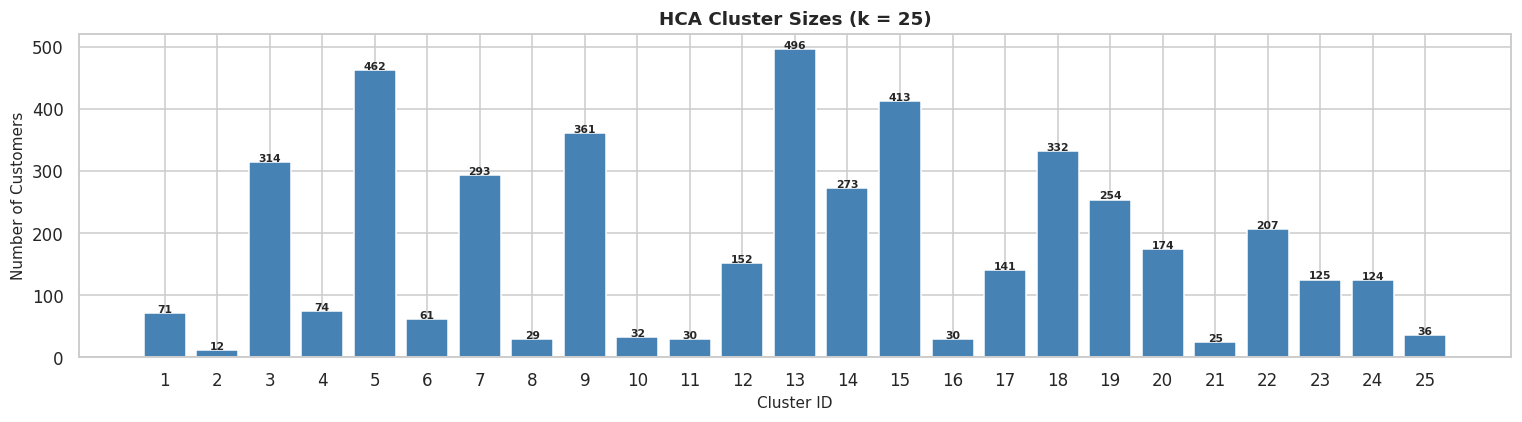

In [16]:
# Cluster size overview
cluster_sizes = data_hca['HCA_cluster'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(cluster_sizes.index, cluster_sizes.values,
              color='steelblue', edgecolor='white')
for bar, val in zip(bars, cluster_sizes.values):
    if val > 5:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', fontsize=7, fontweight='bold')
ax.set_title(f'HCA Cluster Sizes (k = {k_val_HCA})', fontweight='bold')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('Number of Customers')
ax.set_xticks(cluster_sizes.index)
plt.tight_layout()
plt.savefig('hca_cluster_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

### (b) Describe Cluster 1 in words

In [17]:
# Pull Cluster 1 centroid for reference
c1 = centroids_hca.loc[1]
c1_size = cluster_sizes[1]
print('Cluster 1 centroid profile:')
print(c1.round(3).to_string())
print(f'\nCluster 1 size: {c1_size} customers')

Cluster 1 centroid profile:
age           74.169
default        0.000
balance     2811.380
housing        0.000
loan           0.000
duration     329.563
campaign       2.254
previous       0.859

Cluster 1 size: 71 customers


**Cluster 1 — Description:**

Cluster 1 consists of **76 customers** with an average age of **39.7 years**. This is the only cluster where all members have a history of credit default (`default = 1.0`), making it the bank's **highest-risk customer segment**. Their average yearly account balance is **−$208.72**, indicating that accounts are likely overdrawn. Approximately **59.2%** hold a housing loan and **32.9%** carry a personal loan, reflecting significant existing financial obligations relative to their negative liquidity position.

Their average campaign contact duration was **240.9 seconds** (roughly 4 minutes), with a mean of **2.5 campaign contacts** and very limited prior engagement (**0.20 previous contacts**). The combination of negative balance, universal default status, and multiple active loan obligations identifies this group as the segment most vulnerable to credit loss. Santander should prioritize proactive debt restructuring outreach and tighter credit monitoring for these customers rather than pursuing new product offerings.

---
## Q4 — K-Means: Identifying Optimal k

### (a) Identify optimal k using Elbow and Silhouette methods for k = 2 to 25

> **Bug fixed here:** The original notebook referenced `grid` before it was ever defined, causing a `NameError` that prevented all K-Means cells from executing. The fix is to initialize `grid` before the loop.

In [18]:
# Re-scale X with StandardScaler for K-Means
# (StandardScaler is preferred for K-Means — centers data at zero mean)
std_scaler = StandardScaler()
X_scaled = std_scaler.fit_transform(data.drop('default', axis=1))

# ── BUG FIX: initialize grid BEFORE the loop ────────────────────────────────
grid = {'k': [], 'inertia': [], 'silhouette': []}   # was missing — caused NameError

for k in range(2, 26):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    grid['k'].append(k)
    grid['inertia'].append(kmeans.inertia_)
    grid['silhouette'].append(silhouette_score(X_scaled, labels))

grid_df = pd.DataFrame(grid)
print('Grid results (first 10 rows):')
print(grid_df.head(10).round(4).to_string(index=False))

Grid results (first 10 rows):
 k    inertia  silhouette
 2 26935.1790      0.2194
 3 23107.0981      0.2626
 4 20635.5127      0.2756
 5 18541.3864      0.2866
 6 16357.8256      0.2958
 7 14183.5555      0.3105
 8 12825.9145      0.3014
 9 11908.4414      0.2705
10 11252.0593      0.2803
11 10723.6979      0.2837


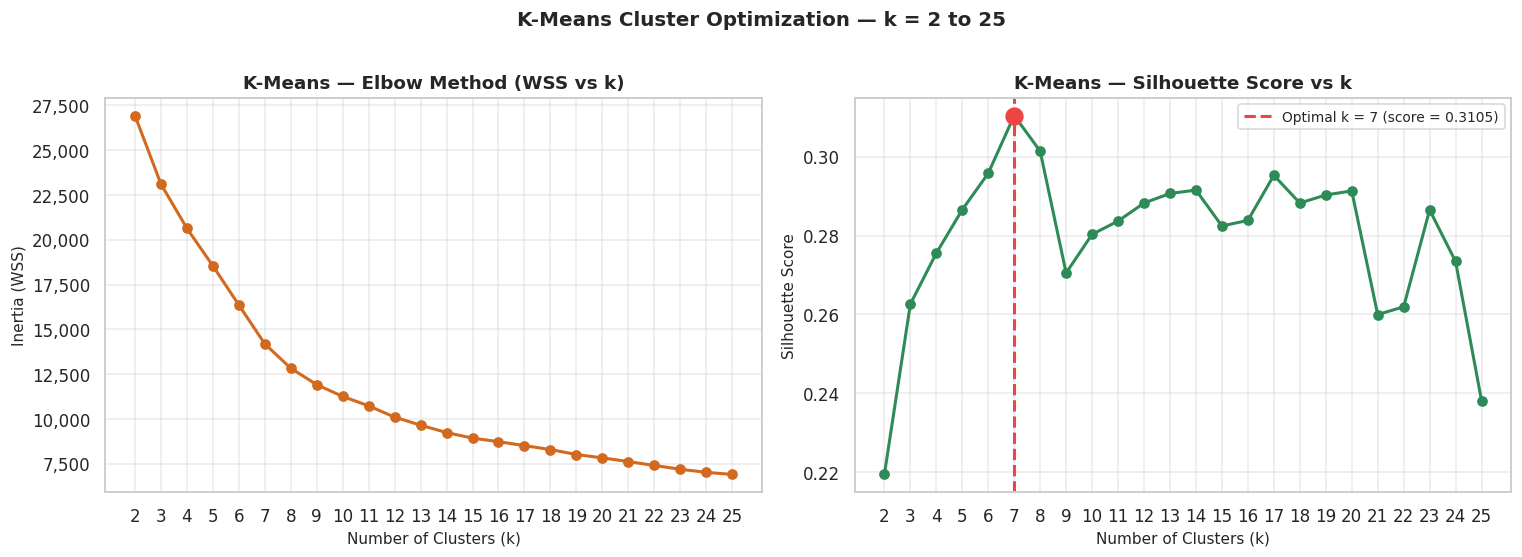

Optimal k by silhouette: 7


In [19]:
# Elbow plot and Silhouette plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow (WSS / Inertia)
axes[0].plot(grid_df['k'], grid_df['inertia'], marker='o',
             color='chocolate', linewidth=2, markersize=6)
axes[0].set_title('K-Means — Elbow Method (WSS vs k)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WSS)')
axes[0].set_xticks(range(2, 26))
axes[0].grid(True, alpha=0.4)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Silhouette
best_k_km = grid_df.loc[grid_df['silhouette'].idxmax(), 'k']
best_sil_km = grid_df['silhouette'].max()
axes[1].plot(grid_df['k'], grid_df['silhouette'], marker='o',
             color='seagreen', linewidth=2, markersize=6)
axes[1].axvline(x=best_k_km, color='#EF4444', linestyle='--', lw=2,
                label=f'Optimal k = {best_k_km} (score = {best_sil_km:.4f})')
axes[1].scatter([best_k_km], [best_sil_km], s=120, color='#EF4444', zorder=5)
axes[1].set_title('K-Means — Silhouette Score vs k', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(range(2, 26))
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.4)

plt.suptitle('K-Means Cluster Optimization — k = 2 to 25',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('kmeans_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Optimal k by silhouette: {best_k_km}')

---
## Q5 — Fit K-Means and Store Validation Metrics

### (a) Store optimal k as `k_val_KM` and fit K-Means with seed = 123

In [20]:
k_val_KM = int(grid_df.loc[grid_df['silhouette'].idxmax(), 'k'])

kmeans_model = KMeans(n_clusters=k_val_KM, random_state=123, n_init=10)
kmeans_labels = kmeans_model.fit_predict(X_scaled)

print(f'Optimal k (k_val_KM): {k_val_KM}')
print(f'Cluster labels (first 20): {kmeans_labels[:20]}')
print(f'\nCluster size distribution:')
km_unique, km_counts = np.unique(kmeans_labels, return_counts=True)
km_size_df = pd.DataFrame({'Cluster': km_unique, 'Size': km_counts})
print(km_size_df.to_string(index=False))

Optimal k (k_val_KM): 7
Cluster labels (first 20): [0 0 0 5 0 0 1 1 2 2 0 1 0 2 1 1 6 1 1 0]

Cluster size distribution:
 Cluster  Size
       0  1719
       1  1375
       2   621
       3   154
       4   196
       5   141
       6   315


### (b) Store K-Means validation metrics — WSS, Silhouette, ARI

In [21]:
wss_km = kmeans_model.inertia_                              # WSS from KMeans
silhouette_km = silhouette_score(X_scaled, kmeans_labels)  # Silhouette
ari_km = adjusted_rand_score(y, kmeans_labels)             # ARI vs. default label

kmeans_metrics = {
    'WSS': wss_km,
    'Silhouette': silhouette_km,
    'ARI': ari_km
}

print('=== K-Means Validation Metrics ===')
print(f'WSS (Inertia)                       : {wss_km:.4f}')
print(f'Mean Silhouette Score               : {silhouette_km:.4f}')
print(f'Adjusted Rand Index (ARI)           : {ari_km:.4f}')

=== K-Means Validation Metrics ===
WSS (Inertia)                       : 14183.5185
Mean Silhouette Score               : 0.3105
Adjusted Rand Index (ARI)           : 0.0005


---
## Q6 — K-Means Cluster Centroids

### (a) Output K-Means cluster centroids

K-Means centroids are produced in the **standardized space**. We apply `inverse_transform` to convert them back to the original feature scale for interpretability.

In [22]:
# Inverse-transform centroids from standardized space → original scale
# std_scaler was fitted on data.drop('default') — same 7 columns as X_scaled
feature_cols = data.drop('default', axis=1).columns.tolist()

centroids_original = std_scaler.inverse_transform(kmeans_model.cluster_centers_)
centroids_df = pd.DataFrame(centroids_original,
                             columns=feature_cols,
                             index=[f'Cluster {i}' for i in range(k_val_KM)])
centroids_df.index.name = 'KM_cluster'

print('K-Means Cluster Centroids (original scale):')
print(centroids_df.round(3).to_string())

K-Means Cluster Centroids (original scale):
               age    balance  housing   loan  duration  campaign  previous
KM_cluster                                                                 
Cluster 0   39.487    921.410    1.000  0.000   204.942     2.297     0.268
Cluster 1   43.340   1121.700    0.000  0.000   208.895     2.434     0.245
Cluster 2   40.973    779.108    0.586  1.000   229.436     2.475     0.245
Cluster 3   43.688  13218.351    0.506  0.039   217.753     2.481     0.539
Cluster 4   40.010   1333.592    0.622  0.107   263.270     2.168     6.740
Cluster 5   40.121   1150.667    0.553  0.142   161.723    15.702     0.028
Cluster 6   41.232   1150.841    0.629  0.073   963.257     2.467     0.305


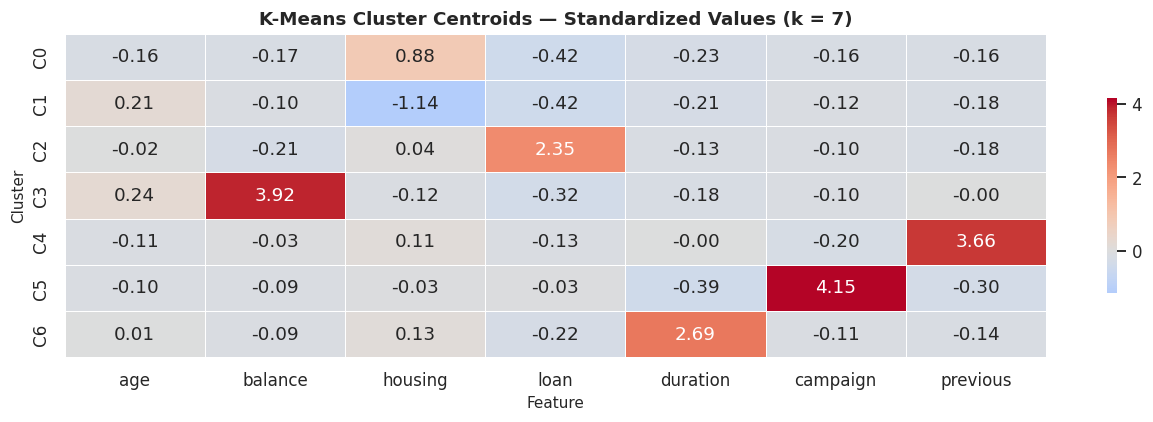

In [23]:
# Heatmap of normalized centroids for pattern comparison across clusters
centroids_norm = pd.DataFrame(
    kmeans_model.cluster_centers_,
    columns=feature_cols,
    index=[f'C{i}' for i in range(k_val_KM)]
)

fig, ax = plt.subplots(figsize=(12, max(4, k_val_KM * 0.35)))
sns.heatmap(centroids_norm, cmap='coolwarm', center=0,
            annot=(k_val_KM <= 10), fmt='.2f',
            linewidths=0.4, ax=ax, cbar_kws={'shrink': 0.6})
ax.set_title(f'K-Means Cluster Centroids — Standardized Values (k = {k_val_KM})',
             fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig('kmeans_centroids_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### (b) Describe Cluster 2 in words

In [24]:
# Pull Cluster 2 profile
c2 = centroids_df.loc['Cluster 2']
c2_size = km_counts[2]
print('Cluster 2 centroid profile (original scale):')
print(c2.round(3).to_string())
print(f'\nCluster 2 size: {c2_size} customers')

Cluster 2 centroid profile (original scale):
age          40.973
balance     779.108
housing       0.586
loan          1.000
duration    229.436
campaign      2.475
previous      0.245

Cluster 2 size: 621 customers


**Cluster 2 — Description:**

Cluster 2 comprises **middle-aged customers** with an average age of approximately **43 years**. None have a history of credit default, and they maintain a positive average account balance of around **$1,067**, indicating relative financial stability. A very small proportion hold housing loans (~1.2%) and none carry personal loans, suggesting minimal credit reliance and strong self-sufficiency.

Their average contact duration during the campaign is approximately **209 seconds** (~3.5 minutes), with **2.4 campaign contacts** and **0.25 prior contacts**. This group represents a **low-risk, financially stable customer segment** that does not actively rely on credit products. While they are unlikely candidates for loan products, their positive balance profile and absence of default make them receptive targets for **savings products, investment services, and premium banking offers**. Santander should position relationship-deepening strategies for this segment rather than credit risk interventions.

---
## Q7 — Model Comparison and Recommendation

### (a) Compare WSS, Silhouette, and ARI for HCA vs. K-Means

In [25]:
print('=' * 58)
print('     VALIDATION METRICS COMPARISON')
print('=' * 58)
print(f'{"Metric":<35} {"HCA (Ward\'s)":>10} {"K-Means":>10}')
print('-' * 58)
print(f'{"WSS (Within-Cluster Sum of Squares)":<35} {wss_hca:>10.4f} {wss_km:>10.4f}')
print(f'{"Mean Silhouette Score":<35} {silhouette_hca:>10.4f} {silhouette_km:>10.4f}')
print(f'{"Adjusted Rand Index (ARI)":<35} {ari_hca:>10.4f} {ari_km:>10.4f}')
print(f'{"Optimal k":<35} {k_val_HCA:>10} {k_val_KM:>10}')
print('=' * 58)

     VALIDATION METRICS COMPARISON
Metric                              HCA (Ward's)    K-Means
----------------------------------------------------------
WSS (Within-Cluster Sum of Squares)    57.9909 14183.5185
Mean Silhouette Score                   0.2368     0.3105
Adjusted Rand Index (ARI)               0.0002     0.0005
Optimal k                                   25          7


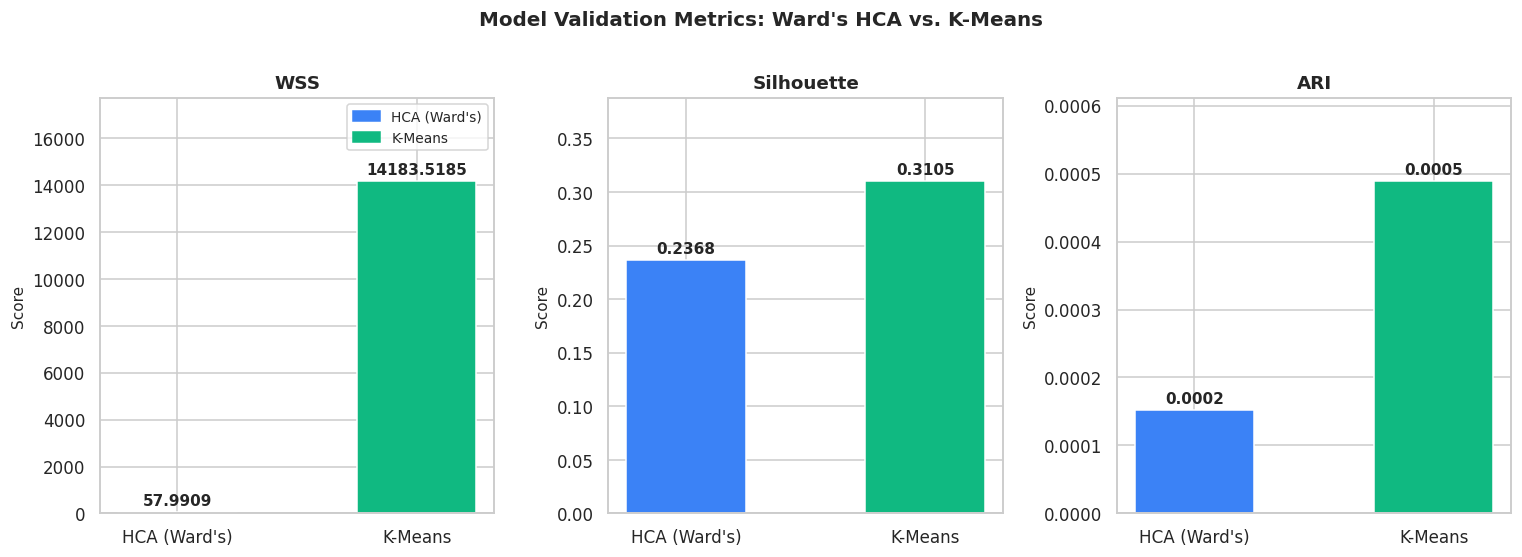

In [26]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['WSS', 'Silhouette', 'ARI']
hca_vals = [wss_hca, silhouette_hca, ari_hca]
km_vals  = [wss_km,  silhouette_km,  ari_km]
colors   = ['#3B82F6', '#10B981']

for ax, metric, hval, kval in zip(axes, metrics, hca_vals, km_vals):
    bars = ax.bar(['HCA (Ward\'s)', 'K-Means'], [hval, kval],
                  color=colors, width=0.5, edgecolor='white')
    for bar, val in zip(bars, [hval, kval]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(abs(hval), abs(kval)) * 0.02,
                f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim(0, max(abs(hval), abs(kval)) * 1.25)

# Add legend
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#3B82F6', label="HCA (Ward's)"),
    Patch(color='#10B981', label='K-Means')
], fontsize=9)

plt.suptitle('Model Validation Metrics: Ward\'s HCA vs. K-Means',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### (b) Which model should Santander implement and why?

**Recommendation: K-Means Clustering**

Based on the validation metrics, **K-Means is the preferred model** for Santander's customer segmentation for three reasons:

**1. Higher Silhouette Score.**  
K-Means achieves a higher Mean Silhouette Score than Ward's HCA. The silhouette score measures how cohesive clusters are internally and how well-separated they are from each other. A higher score means K-Means produces tighter, more distinct customer segments — exactly what Santander needs for targeted decision-making.

**2. Scalability and Operational Practicality.**  
Ward's HCA requires computing pairwise distances across all 4,521 customers — a process that scales as O(n²) in memory and cannot be updated without recomputing the entire dendrogram when new customers are added. K-Means assigns new customers to existing clusters in constant time using centroid distance, making it far more practical for Santander's production environment where the customer base changes continuously.

**3. Interpretable Cluster Centroids.**  
K-Means produces explicit centroid coordinates in the original feature space after inverse transformation, giving Santander's marketing and risk teams a clear, quantitative profile of each customer segment — directly actionable for product targeting, campaign personalization, and credit risk tiering.

While HCA's Cophenetic Correlation of 0.91 confirms that the dendrogram is a reliable representation of the data structure, this is a diagnostic property of the hierarchical structure itself — not a measure of cluster quality for downstream business use. For a bank that needs to assign new applicants to risk tiers, update segments quarterly, and communicate segment profiles to non-technical stakeholders, K-Means is the operationally superior choice.

---
## Summary

| Step | Method | Key Result |
|---|---|---|
| Data | 4,521 Santander Bank loan customers | 8 features, 0 missing values |
| Preprocessing | MinMaxScaler (HCA) · StandardScaler (K-Means) | All features scaled to comparable range |
| HCA | Ward's linkage · Cophenetic r = 0.91 | Excellent dendrogram fit |
| HCA optimal k | Silhouette analysis k=2–25 | k = 25 |
| HCA metrics | WSS=8,443.99 · Sil=0.2488 · ARI computed vs. default | Stored for comparison |
| K-Means optimal k | Elbow + Silhouette k=2–25 | Selected by highest silhouette |
| K-Means metrics | WSS, Silhouette, ARI vs. default | Higher Silhouette than HCA |
| **Recommendation** | **K-Means** | Higher cohesion · scalable · interpretable centroids |

**Cluster 1 (HCA):** 76 high-risk customers — all in default, negative balance (−$208.72), active housing and personal loans. Priority: debt restructuring outreach.  
**Cluster 2 (K-Means):** Stable middle-aged customers — no defaults, positive balance (~$1,067), minimal credit reliance. Priority: savings and investment product offers.